In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy import integrate
import warnings
from scipy.integrate import IntegrationWarning
from scipy.stats import gaussian_kde
from value_function import Firm_1
from value_function import Firm_2

Parameters:

In [ ]:
prod_0=1
r=0.05
sig=0.1
a=0.1
b=0.1
c=0.1
w_1=0.02
w_2=0.02
T=85
alpha=np.zeros(1000)
eta=0.1*np.ones(1000)
scenario="SSP1-26"
sector="Industrial Sector"
AP=1
beta=0
lambda_0=0.05
region="World"
time=np.linspace(0,T,1000)
time_grid_plt=[time<=85]
time_grid_plt = np.flatnonzero(time_grid_plt)
SCENARIOS=["SSP1-26",
                "SSP2-45",
                "SSP4-60",
                "SSP3-70 (Baseline)",
                "SSP5-85 (Baseline)"]
SCENARIOS_temp=["SSP1 - 2.6","SSP2 - 4.5",
        "SSP4 - 6.0","SSP3 - Baseline","SSP5 - Baseline"]   

years_label=["2015","2020","2030","2040","2050","2060","2070","2080","2090","2100"]
years_smooth=np.linspace(int(years_label[0]),int(years_label[-1]),len(time_grid_plt))

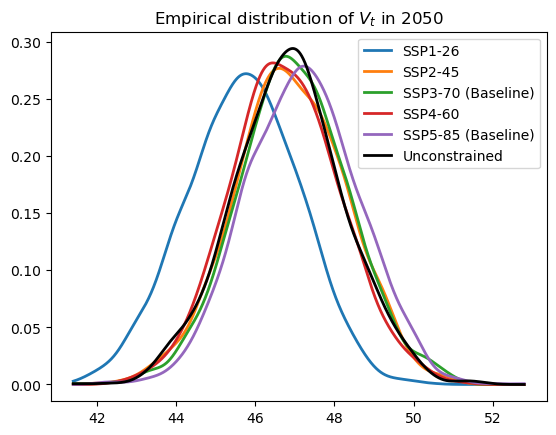

In [3]:
value_distri=np.empty((6,2000))
firm=Firm_1(prod_0,r,sig,a,b,c,0,0,T,alpha,eta,scenario,sector,AP,beta,0,region,time,"SSP5 - Baseline")
#firm.plot_trajectoire_pt()

for i in range(2000):
    value_distri[0,i]=firm.value_funcion(firm._trajectoire_pt(SCENARIOS[0],SCENARIOS_temp[0])[int(35*300/85)],35)

for j in range (len(SCENARIOS)):
    firm=Firm_1(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,SCENARIOS[j],sector,AP,beta,0,region,time,SCENARIOS_temp[j])
    for i in range(2000):
        value_distri[j+1,i]=firm.value_funcion(firm._trajectoire_pt(SCENARIOS[j],SCENARIOS_temp[j])[int(35*300/85)],35)

x=np.linspace(np.min(value_distri),np.max(value_distri),2000)
for i in range(5):
    kde=gaussian_kde(value_distri[i+1,])
    plt.plot(x,kde(x),label=SCENARIOS[i],linewidth=2)
plt.plot(x,gaussian_kde(value_distri[0,])(x),label="Unconstrained",linewidth=2,color='black')
plt.legend()
plt.title(r'Empirical distribution of $V_t$ in 2050')
plt.show()

In [3]:
firm=Firm_1(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,scenario,sector,AP,beta,1,region,time,"SSP5 - Baseline")

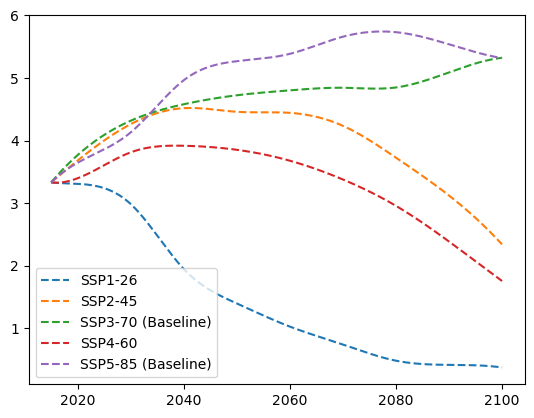

In [4]:
for scen in SCENARIOS:
    firm=Firm_1(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,scen,sector,AP,beta,0,region,time,"SSP5 - Baseline")
    plt.plot(years_smooth,firm.input_emission()[time_grid_plt],label=scen,linestyle='--')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Optimal emission $\\hat{\\gamma}_t$ over time')

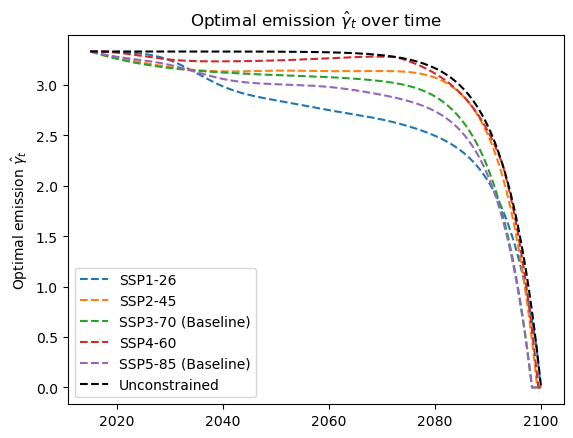

In [5]:
for scen in SCENARIOS:
    plt.plot(years_smooth,firm.gamma_optimal_control(scen)[time_grid_plt],linestyle='--',label=scen)
plt.plot(years_smooth,firm.gamma_optimal_unconstrained()[time_grid_plt],linestyle='--',color='black',label='Unconstrained')
plt.legend()
plt.ylabel(r"Optimal emission $\hat{\gamma}_t$")
plt.title(r"Optimal emission $\hat{\gamma}_t$ over time")

Text(0.5, 1.0, 'Optimal log-production $\\hat{p}_t$ over time')

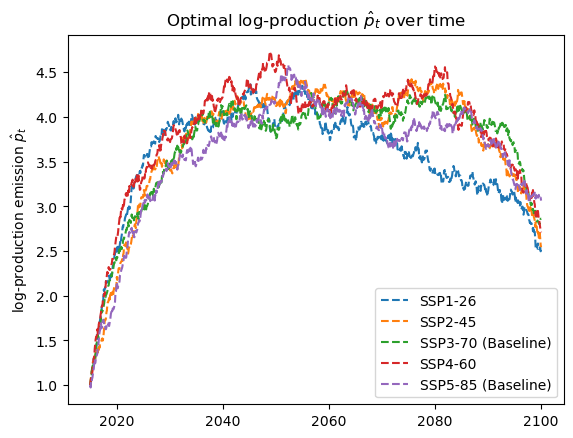

In [62]:
firm=Firm_1(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,scenario,sector,AP,beta,0,region,time,"SSP5 - Baseline")

for i in range (5):
    plt.plot(years_smooth,firm._trajectoire_pt(SCENARIOS[i],SCENARIOS_temp[i]),label=SCENARIOS[i],linestyle='--')
plt.legend()
plt.ylabel(r"log-production emission $\hat{p}_t$")
plt.title(r"Optimal log-production $\hat{p}_t$ over time")

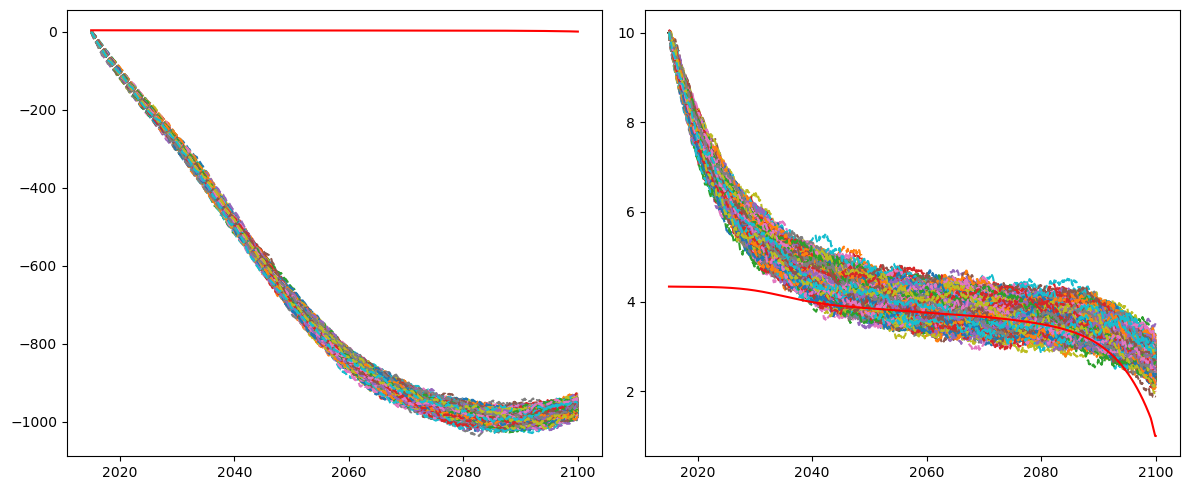

In [ ]:
firm=Firm_1(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,scenario,sector,AP,beta,0,region,time,"SSP5 - Baseline")
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)  # 1 ligne, 2 colonnes, plot 1

for i in range (1000):   
    plt.plot(years_smooth,firm._trajectoire_pt(SCENARIOS[0],SCENARIOS_temp[0]),label=SCENARIOS[0],linestyle='--')
plt.plot(years_smooth,(a+c*firm.gamma_optimal_control(SCENARIOS[0]))/b,color='red')

firm=Firm_1(10,r,sig,a,b,c,w_1,w_2,T,alpha,eta,scenario,sector,AP,beta,0,region,time,"SSP5 - Baseline")
plt.subplot(1, 2, 2)  # plot 2

for i in range (1000):   
    plt.plot(years_smooth,firm._trajectoire_pt(SCENARIOS[0],SCENARIOS_temp[0]),label=SCENARIOS[0],linestyle='--')
plt.plot(years_smooth,(a+c*firm.gamma_optimal_control(SCENARIOS[0]))/b,color='red')
plt.tight_layout()
plt.show()

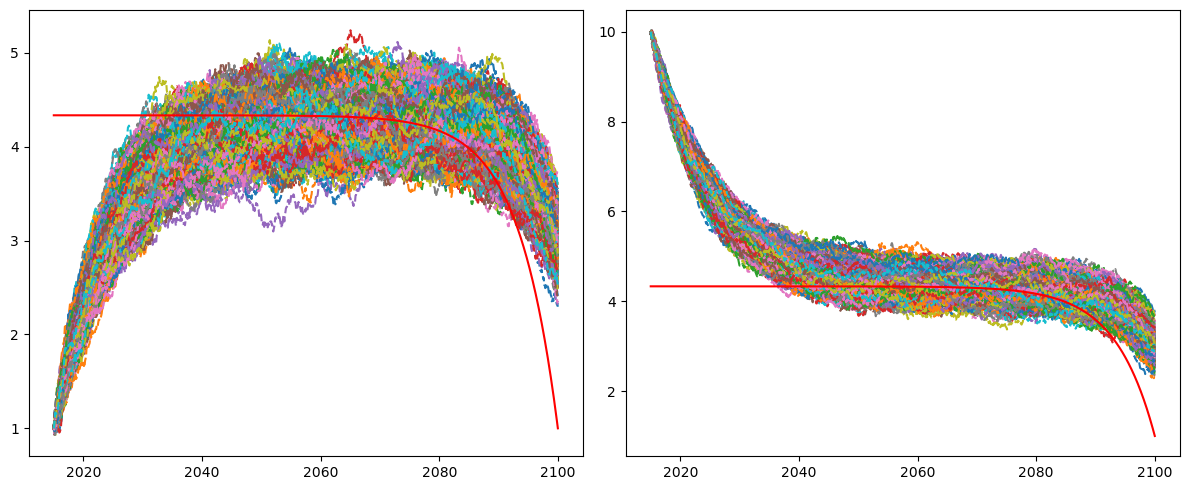

In [64]:
firm=Firm_1(prod_0,r,sig,a,b,c,0,0,T,alpha,eta,scenario,sector,AP,beta,0,region,time,"SSP1-26")
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)  # 1 ligne, 2 colonnes, plot 1
for i in range (1000):   
    plt.plot(years_smooth,firm._trajectoire_pt(SCENARIOS[0],SCENARIOS_temp[0]),label=SCENARIOS[0],linestyle='--')
plt.plot(years_smooth,(a+c*firm.gamma_optimal_unconstrained())/b,color='red')

plt.subplot(1, 2, 2)  # plot 2

firm=Firm_1(10,r,sig,a,b,c,0,0,T,alpha,eta,scenario,sector,AP,beta,0,region,time,"SSP1-26")
for i in range (1000):   
    plt.plot(years_smooth,firm._trajectoire_pt(SCENARIOS[0],SCENARIOS_temp[0]),label=SCENARIOS[0],linestyle='--')
plt.plot(years_smooth,(a+c*firm.gamma_optimal_unconstrained())/b,color='red')
plt.tight_layout()
plt.show()

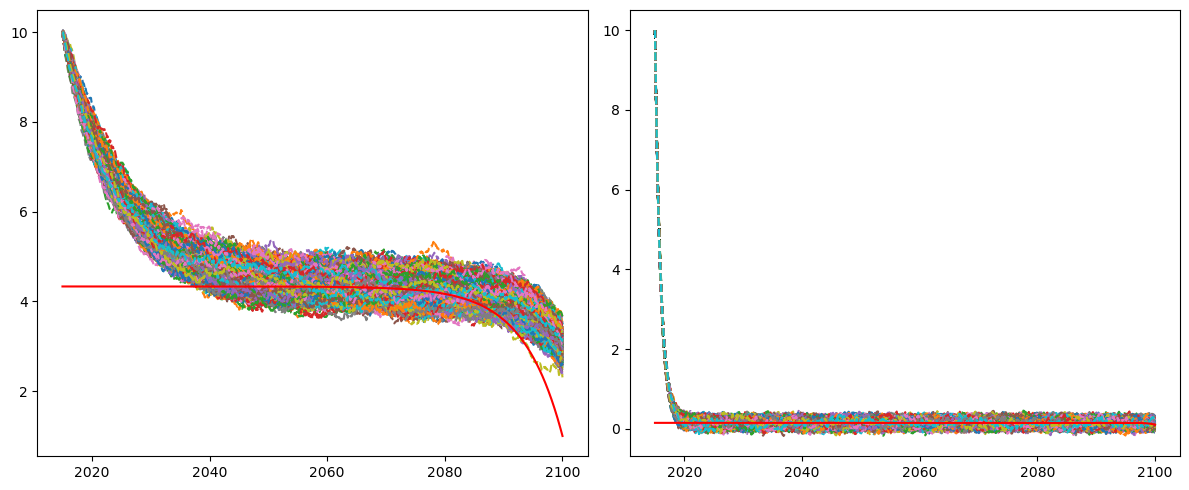

In [65]:
firm=Firm_1(10,r,sig,a,b,c,0,0,T,alpha,eta,scenario,sector,AP,beta,0,region,time,"SSP1-26")
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)  # 1 ligne, 2 colonnes, plot 1
for i in range (1000):   
    plt.plot(years_smooth,firm._trajectoire_pt(SCENARIOS[0],SCENARIOS_temp[0]),label=SCENARIOS[0],linestyle='--')
plt.plot(years_smooth,(a+c*firm.gamma_optimal_unconstrained())/b,color='red')

plt.subplot(1, 2, 2)  # plot 2

firm=Firm_1(10,r,sig,a,10*b,c,0,0,T,alpha,eta,scenario,sector,AP,beta,0,region,time,"SSP1-26")
for i in range (1000):   
    plt.plot(years_smooth,firm._trajectoire_pt(SCENARIOS[0],SCENARIOS_temp[0]),label=SCENARIOS[0],linestyle='--')
plt.plot(years_smooth,(a+c*firm.gamma_optimal_unconstrained())/(10*b),color='red')
plt.tight_layout()
plt.show()

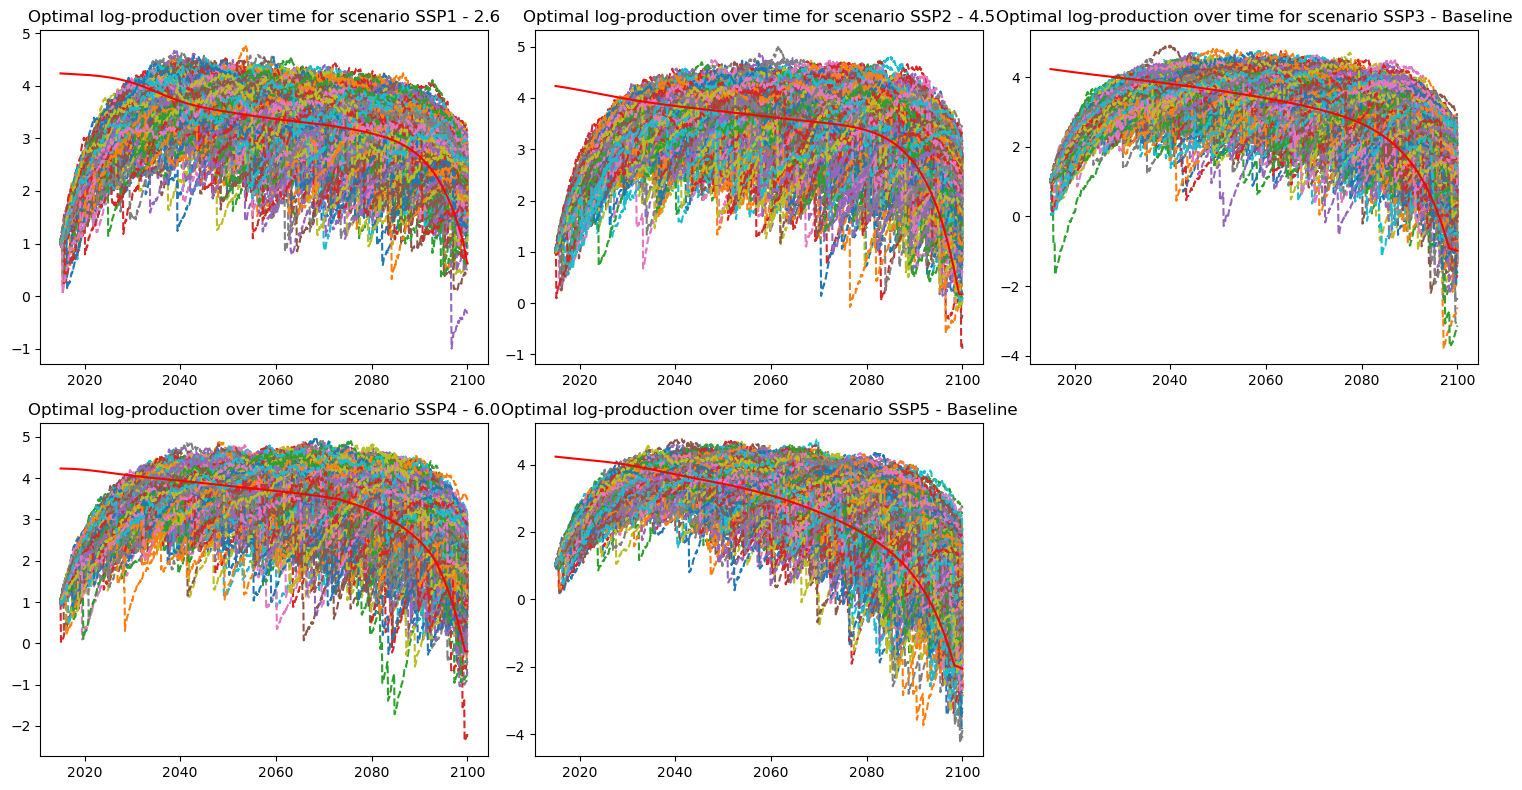

In [66]:
fig, ax = plt.subplots(2, 3, figsize=(15,8))

ax = ax.flatten()  # pour itérer facilement
for i in range (5):
    firm=Firm_1(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,SCENARIOS[i],sector,AP,beta,0.01,region,time,SCENARIOS_temp[i])
    for j in range (500):
        ax[i].plot(years_smooth,firm._trajectoire_pt(SCENARIOS[i],SCENARIOS_temp[i]),label=SCENARIOS[i],linestyle='--')
    ax[i].plot(years_smooth,(a+c*firm.gamma_optimal_control(SCENARIOS[i])-firm.trajectoire_lambda(SCENARIOS_temp[i]))/b,color='red')
    ax[i].set_title(f"Optimal log-production over time for scenario {SCENARIOS_temp[i]}")
fig.delaxes(ax[5])
plt.tight_layout()
plt.show()

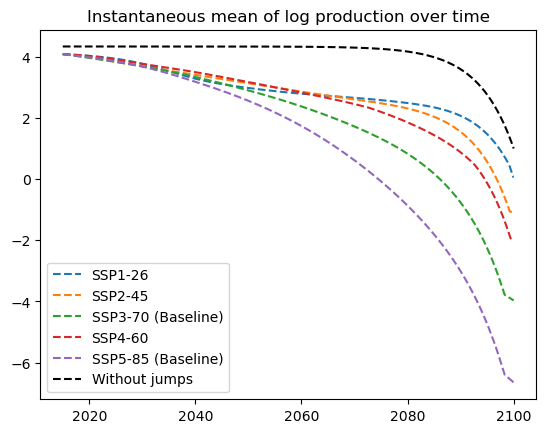

In [4]:
for i in range (5):
    firm=Firm_1(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,SCENARIOS[i],sector,AP,beta,0.025,region,time,SCENARIOS_temp[i])
    plt.plot(years_smooth,(a+c*firm.gamma_optimal_control(SCENARIOS[i])-firm.trajectoire_lambda(SCENARIOS_temp[i]))/b,label=SCENARIOS[i],linestyle='--')
plt.plot(years_smooth,(a+c*firm.gamma_optimal_unconstrained())/b,label="Without jumps",linestyle='--',color="black")
plt.title("Instantaneous mean of log production over time")
plt.legend()

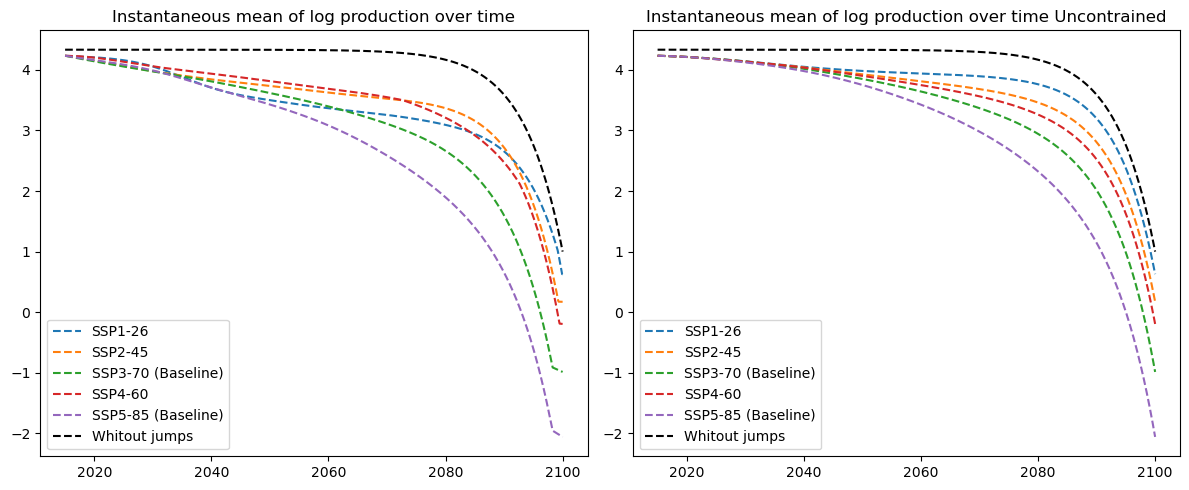

In [23]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
for i in range (5):
    firm=Firm_1(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,SCENARIOS[i],sector,AP,beta,0.01,region,time,SCENARIOS_temp[i])
    plt.plot(years_smooth,(a+c*firm.gamma_optimal_control(SCENARIOS[i])-firm.trajectoire_lambda(SCENARIOS_temp[i]))/b,label=SCENARIOS[i],linestyle='--')
plt.plot(years_smooth,(a+c*firm.gamma_optimal_unconstrained())/b,label="Whitout jumps",linestyle='--',color="black")
plt.title("Instantaneous mean of log production over time")
plt.legend()

plt.subplot(1,2,2)
for i in range (5):
    firm=Firm_1(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,SCENARIOS[i],sector,AP,beta,0.01,region,time,SCENARIOS_temp[i])
    plt.plot(years_smooth,(a+c*firm.gamma_optimal_unconstrained()-firm.trajectoire_lambda(SCENARIOS_temp[i]))/b,label=SCENARIOS[i],linestyle='--')
plt.plot(years_smooth,(a+c*firm.gamma_optimal_unconstrained())/b,label="Whitout jumps",linestyle='--',color="black")
plt.title("Instantaneous mean of log production over time Uncontrained")

plt.legend()
plt.tight_layout()
plt.show()


In [5]:
firm=Firm_2(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,scenario,sector,AP,beta,0.01,region,time,"SSP5 - Baseline")
Firm=Firm_1(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,scenario,sector,AP,beta,0.01,region,time,"SSP5 - Baseline")



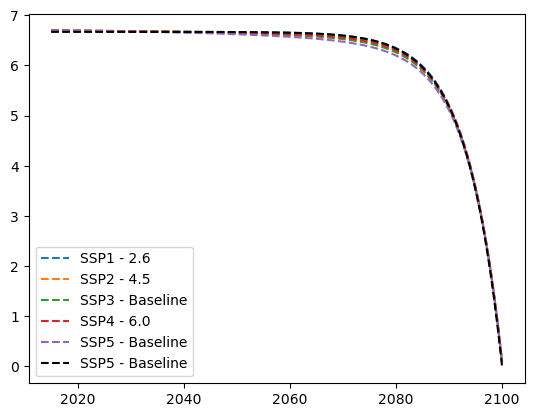

In [10]:
for scen in SCENARIOS_temp:
    plt.plot(years_smooth,firm.B_grid(scen)[time_grid_plt],label=scen,linestyle='--')
plt.plot(years_smooth,Firm.B_t()[time_grid_plt],label=scen,linestyle='--',color='black')
plt.legend()


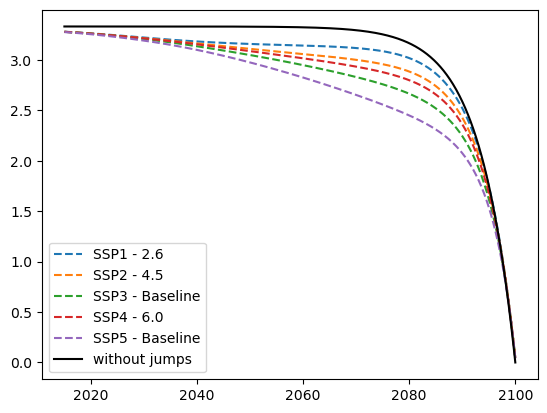

In [10]:
for scen in SCENARIOS_temp:
    plt.plot(years_smooth,firm.gamma_optimal_unconstrained(scen)[time_grid_plt],label=scen,linestyle='--')
firm2=Firm_1(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,SCENARIOS[0],sector,AP,beta,0,region,time,SCENARIOS_temp[0])
plt.plot(years_smooth,firm2.gamma_optimal_unconstrained()[time_grid_plt],label='without jumps',color='black')
plt.legend()


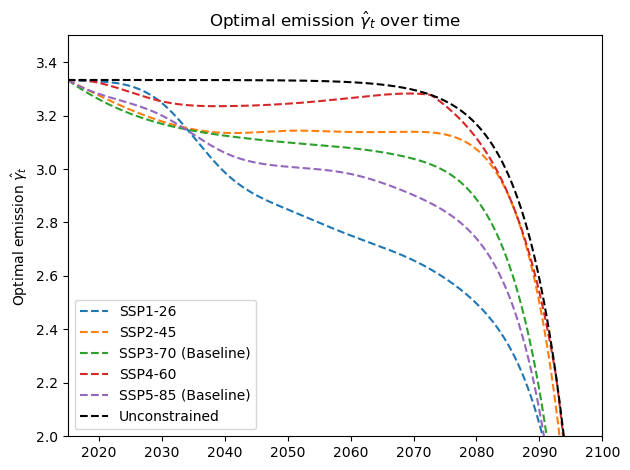

In [25]:

firm2=Firm_1(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,SCENARIOS[0],sector,AP,beta,0,region,time,SCENARIOS_temp[0])

for scen in SCENARIOS:
    plt.plot(years_smooth,firm2.gamma_optimal_control(scen),linestyle='--',label=scen)
plt.plot(years_smooth,firm2.gamma_optimal_unconstrained(),linestyle='--',color='black',label='Unconstrained')
plt.legend()
plt.ylabel(r"Optimal emission $\hat{\gamma}_t$")
plt.title(r"Optimal emission $\hat{\gamma}_t$ over time")
plt.xlim(2015,2100)
plt.ylim(2,3.5)
plt.tight_layout()
plt.show()

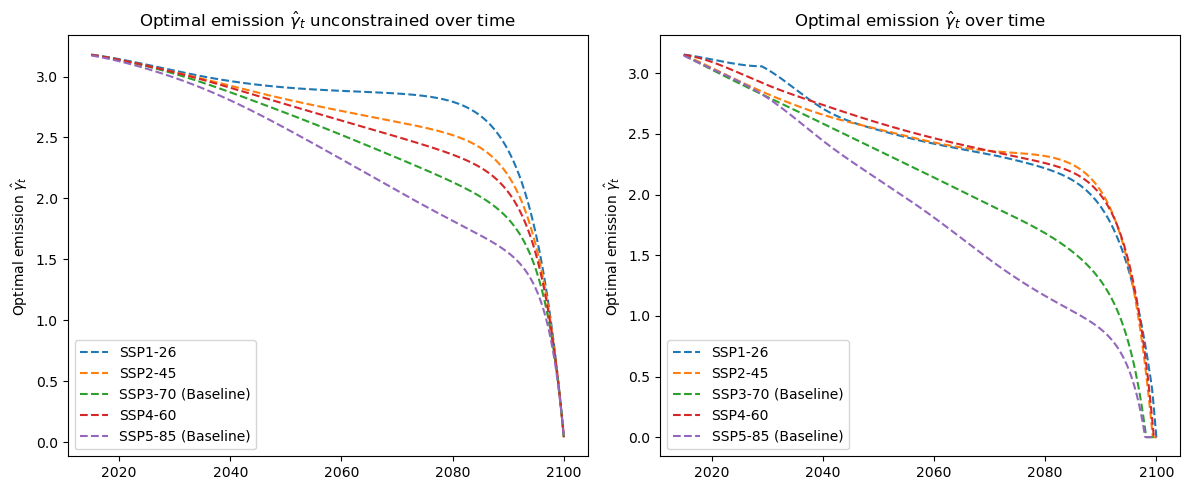

In [15]:
plt.figure(figsize=(12,5))

firm2=Firm_2(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,SCENARIOS[0],sector,AP,beta,0.025,region,time,SCENARIOS_temp[0])
plt.subplot(1, 2, 1)  # 1 ligne, 2 colonnes, plot 1
for j in range (len(SCENARIOS)):
    plt.plot(years_smooth,firm2.gamma_optimal_unconstrained(SCENARIOS_temp[j]),linestyle='--',label=SCENARIOS[j])
plt.legend()
plt.ylabel(r"Optimal emission $\hat{\gamma}_t$")
plt.title(r"Optimal emission $\hat{\gamma}_t$ unconstrained over time")



plt.subplot(1, 2, 2)  # 1 ligne, 2 colonnes, plot 1

for j in range (len(SCENARIOS)):
    plt.plot(years_smooth,firm2.gamma_optimal_control(SCENARIOS_temp[j],SCENARIOS[j]),linestyle='--',label=SCENARIOS[j])
plt.legend()
plt.ylabel(r"Optimal emission $\hat{\gamma}_t$")
plt.title(r"Optimal emission $\hat{\gamma}_t$ over time")
plt.tight_layout()
plt.show()

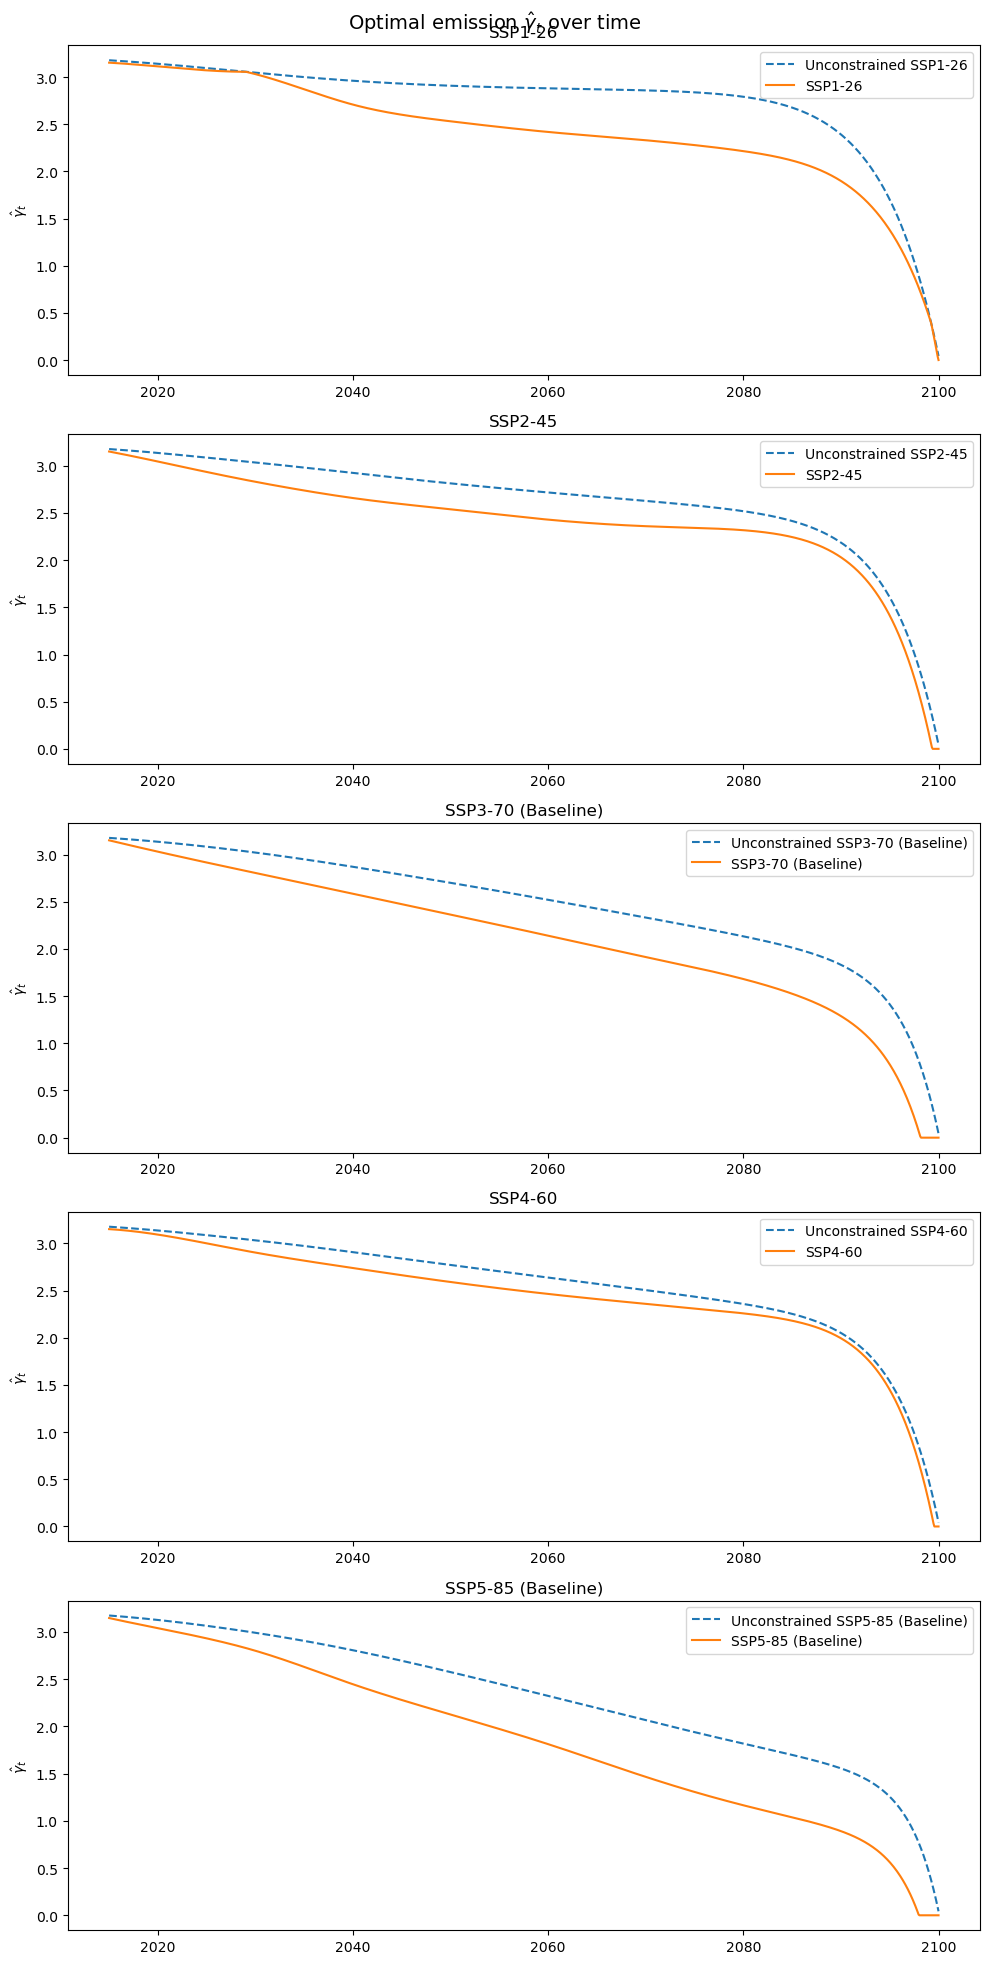

In [16]:
fig, axes = plt.subplots(len(SCENARIOS), 1, figsize=(10, 4*len(SCENARIOS)))

for j in range(len(SCENARIOS)):
    axes[j].plot(years_smooth, firm2.gamma_optimal_unconstrained(SCENARIOS_temp[j]), 
                 linestyle='--', label=f"Unconstrained {SCENARIOS[j]}")
    axes[j].plot(years_smooth, firm2.gamma_optimal_control(SCENARIOS_temp[j], SCENARIOS[j]), 
                 linestyle='-', label=SCENARIOS[j])
    axes[j].legend()
    axes[j].set_title(SCENARIOS[j])
    axes[j].set_ylabel(r"$\hat{\gamma}_t$")

fig.suptitle(r"Optimal emission $\hat{\gamma}_t$ over time", fontsize=14)
plt.tight_layout()
plt.show()

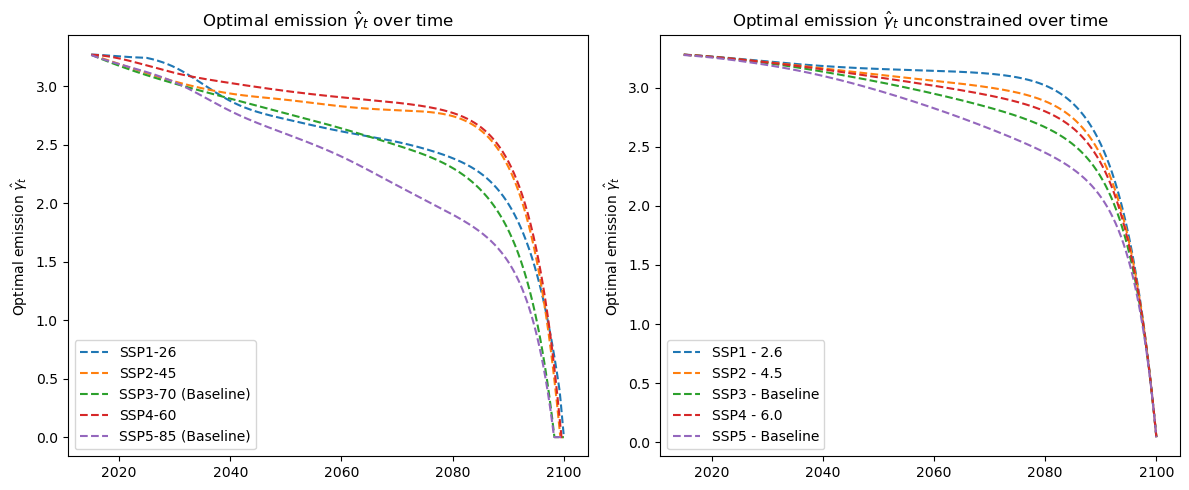

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)  # 1 ligne, 2 colonnes, plot 1
for i in range(len(SCENARIOS_temp)):
    plt.plot(years_smooth,firm.gamma_optimal_control(SCENARIOS_temp[i],SCENARIOS[i])[time_grid_plt],label=SCENARIOS[i],linestyle='--')
plt.legend()
plt.ylabel(r"Optimal emission $\hat{\gamma}_t$")
plt.title(r"Optimal emission $\hat{\gamma}_t$ over time")

plt.subplot(1, 2, 2)  # 1 ligne, 2 colonnes, plot 1

for scen in SCENARIOS_temp:
    plt.plot(years_smooth,firm.gamma_optimal_unconstrained(scen)[time_grid_plt],label=scen,linestyle='--')
plt.legend()
plt.ylabel(r"Optimal emission $\hat{\gamma}_t$")
plt.title(r"Optimal emission $\hat{\gamma}_t$ unconstrained over time")
plt.tight_layout()

plt.show()


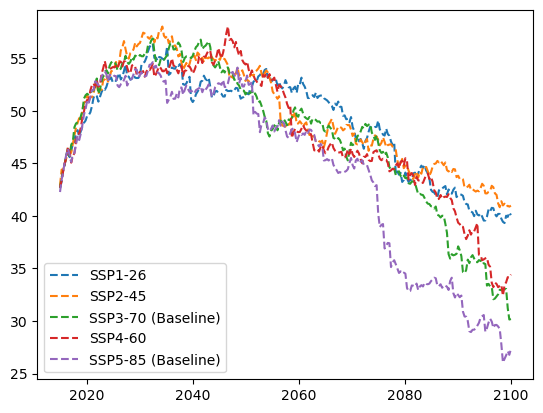

In [30]:
for i in range(len(SCENARIOS_temp)):
    plt.plot(years_smooth,firm.trajectoire_value_function(SCENARIOS[i],SCENARIOS_temp[i])[time_grid_plt],label=SCENARIOS[i],linestyle='--')
plt.legend()


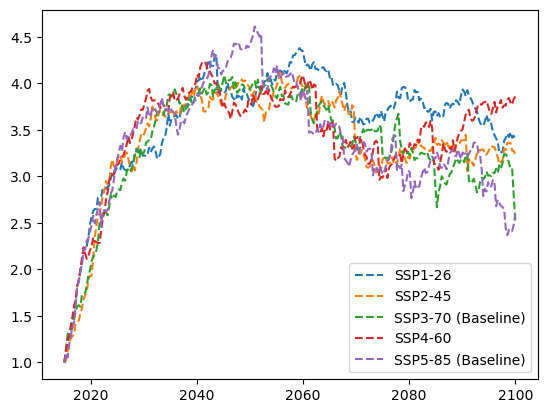

In [31]:
for i in range(len(SCENARIOS_temp)):
    plt.plot(years_smooth,firm._trajectoire_pt(SCENARIOS[i],SCENARIOS_temp[i])[time_grid_plt],label=SCENARIOS[i],linestyle='--')
plt.legend()

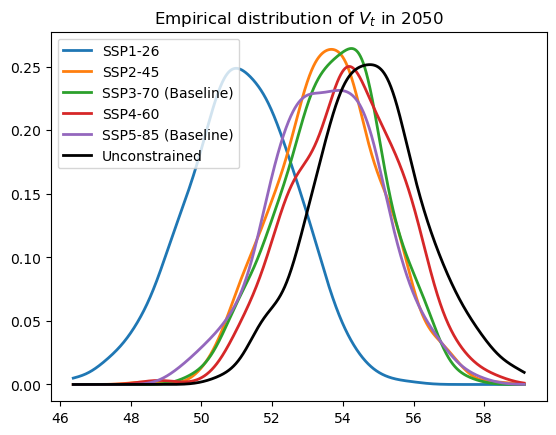

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

N_MC = 500
n = len(time)

# t0 = 35 (ex: 2050 dans ton échelle)
t0 = 35
k0 = int(t0 * n / 85)

value_distri = np.empty((6, N_MC))

# -------------------------
# 0) Unconstrained (w1=w2=0)
# -------------------------
firm = Firm_2(prod_0, r, sig, a, b, c,
              0, 0, T, alpha, eta,
              scenario, sector, AP, beta, 0, region, time,
              "SSP5 - Baseline")

for i in range(N_MC):
    traj = firm._trajectoire_pt(SCENARIOS[0], SCENARIOS_temp[0])
    value_distri[0, i] = firm.value_funcion(traj[k0], t0, SCENARIOS[0], SCENARIOS_temp[0])

# -------------------------
# 1..5) Scénarios contraints
# -------------------------
for j in range(len(SCENARIOS)):
    firm = Firm_2(prod_0, r, sig, a, b, c,
                  w_1, w_2, T, alpha, eta,
                  SCENARIOS[j], sector, AP, beta, 0, region, time,
                  SCENARIOS_temp[j])

    for i in range(N_MC):
        traj = firm._trajectoire_pt(SCENARIOS[j], SCENARIOS_temp[j])
        value_distri[j+1, i] = firm.value_funcion(traj[k0], t0, SCENARIOS[j], SCENARIOS_temp[j])

# -------------------------
# KDE + plot
# -------------------------
x = np.linspace(np.min(value_distri), np.max(value_distri), 2000)

for j in range(len(SCENARIOS)):
    kde = gaussian_kde(value_distri[j+1, :])
    plt.plot(x, kde(x), label=SCENARIOS[j], linewidth=2)

plt.plot(x, gaussian_kde(value_distri[0, :])(x), label="Unconstrained", linewidth=2, color="black")

plt.legend()
plt.title(r'Empirical distribution of $V_t$ in 2050')
plt.show()

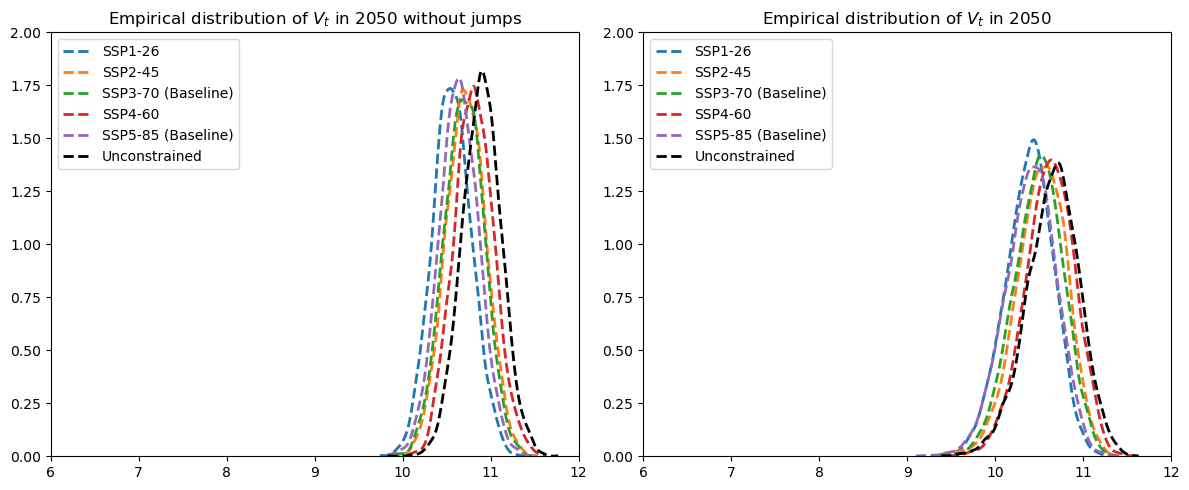

In [18]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)  # 1 ligne, 2 colonnes, plot 1
firm=Firm_1(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,scenario,sector,AP,beta,0,region,time,"SSP5 - Baseline")
n=5000
for i in range(len(SCENARIOS)):
    value_distri=firm.multi_value(SCENARIOS[i],SCENARIOS_temp[i],n,35)
    x = np.linspace(np.min(value_distri), np.max(value_distri), n)
    kde = gaussian_kde(value_distri)
    plt.plot(x, kde(x), label=SCENARIOS[i], linewidth=2,linestyle='--')

firm=Firm_1(prod_0,r,sig,a,b,c,0,0,T,alpha,eta,scenario,sector,AP,beta,0,region,time,"SSP5 - Baseline")
value_distri=firm.multi_value(SCENARIOS[i],SCENARIOS_temp[i],n,35)
x = np.linspace(np.min(value_distri), np.max(value_distri), n)
kde = gaussian_kde(value_distri)
plt.plot(x, kde(x), label="Unconstrained",color="black", linewidth=2,linestyle='--')
plt.xlim(6,12)
plt.ylim(0,2)
plt.legend()
plt.title(r'Empirical distribution of $V_t$ in 2050 without jumps')

plt.subplot(1, 2, 2)  # 1 ligne, 2 colonnes, plot 1
firm=Firm_1(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,scenario,sector,AP,beta,0.025,region,time,"SSP5 - Baseline")
for i in range(len(SCENARIOS)):
    value_distri=firm.multi_value(SCENARIOS[i],SCENARIOS_temp[i],n,35)
    x = np.linspace(np.min(value_distri), np.max(value_distri), n)
    kde = gaussian_kde(value_distri)
    plt.plot(x, kde(x), label=SCENARIOS[i], linewidth=2,linestyle='--')

firm=Firm_1(prod_0,r,sig,a,b,c,0,0,T,alpha,eta,scenario,sector,AP,beta,0.025,region,time,"SSP5 - Baseline")
value_distri=firm.multi_value(SCENARIOS[i],SCENARIOS_temp[i],n,35)
x = np.linspace(np.min(value_distri), np.max(value_distri), n)
kde = gaussian_kde(value_distri)
plt.plot(x, kde(x), label="Unconstrained",color="black", linewidth=2,linestyle='--')
plt.xlim(6,12)
plt.ylim(0,2)
plt.legend()
plt.title(r'Empirical distribution of $V_t$ in 2050')
plt.tight_layout()
plt.show()

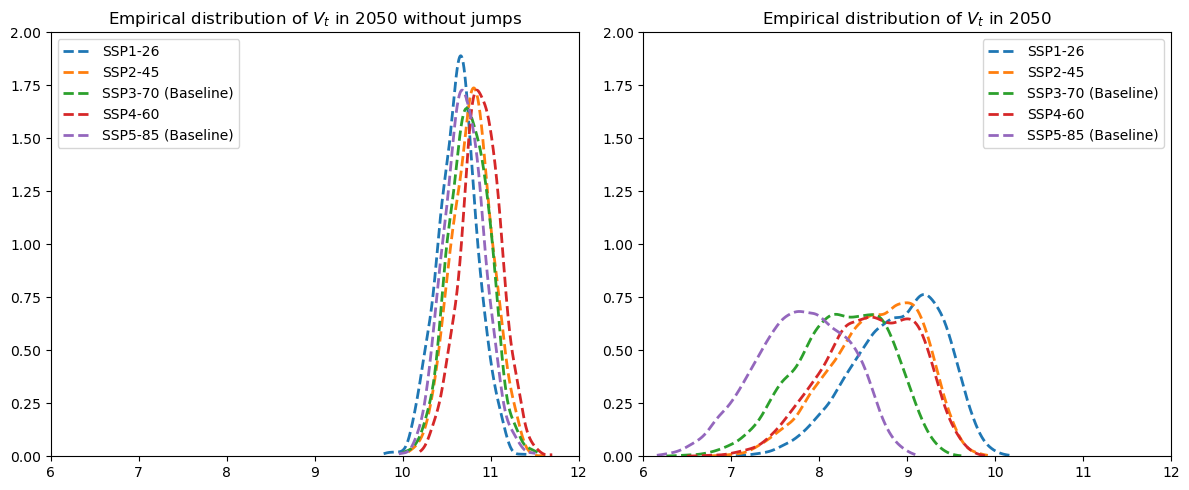

In [11]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)  # 1 ligne, 2 colonnes, plot 1
firm=Firm_2(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,scenario,sector,AP,beta,0,region,time,"SSP5 - Baseline")
n=1000
for i in range(len(SCENARIOS)):
    value_distri=firm.multi_value(SCENARIOS[i],SCENARIOS_temp[i],n,35)
    x = np.linspace(np.min(value_distri), np.max(value_distri), n)
    kde = gaussian_kde(value_distri)
    plt.plot(x, kde(x), label=SCENARIOS[i], linewidth=2,linestyle='--')
plt.legend()
plt.xlim(6,12)
plt.ylim(0,2)
plt.title(r'Empirical distribution of $V_t$ in 2050 without jumps')


plt.subplot(1, 2, 2)  # 1 ligne, 2 colonnes, plot 1
firm=Firm_2(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,scenario,sector,AP,beta,0.025,region,time,"SSP5 - Baseline")
n=10000
for i in range(len(SCENARIOS)):
    value_distri=firm.multi_value(SCENARIOS[i],SCENARIOS_temp[i],n,35)
    x = np.linspace(np.min(value_distri), np.max(value_distri), n)
    kde = gaussian_kde(value_distri)
    plt.plot(x, kde(x), label=SCENARIOS[i], linewidth=2,linestyle='--')
plt.legend()
plt.ylim(0,2)
plt.xlim(6,12)
plt.title(r'Empirical distribution of $V_t$ in 2050')
plt.tight_layout()
plt.show()

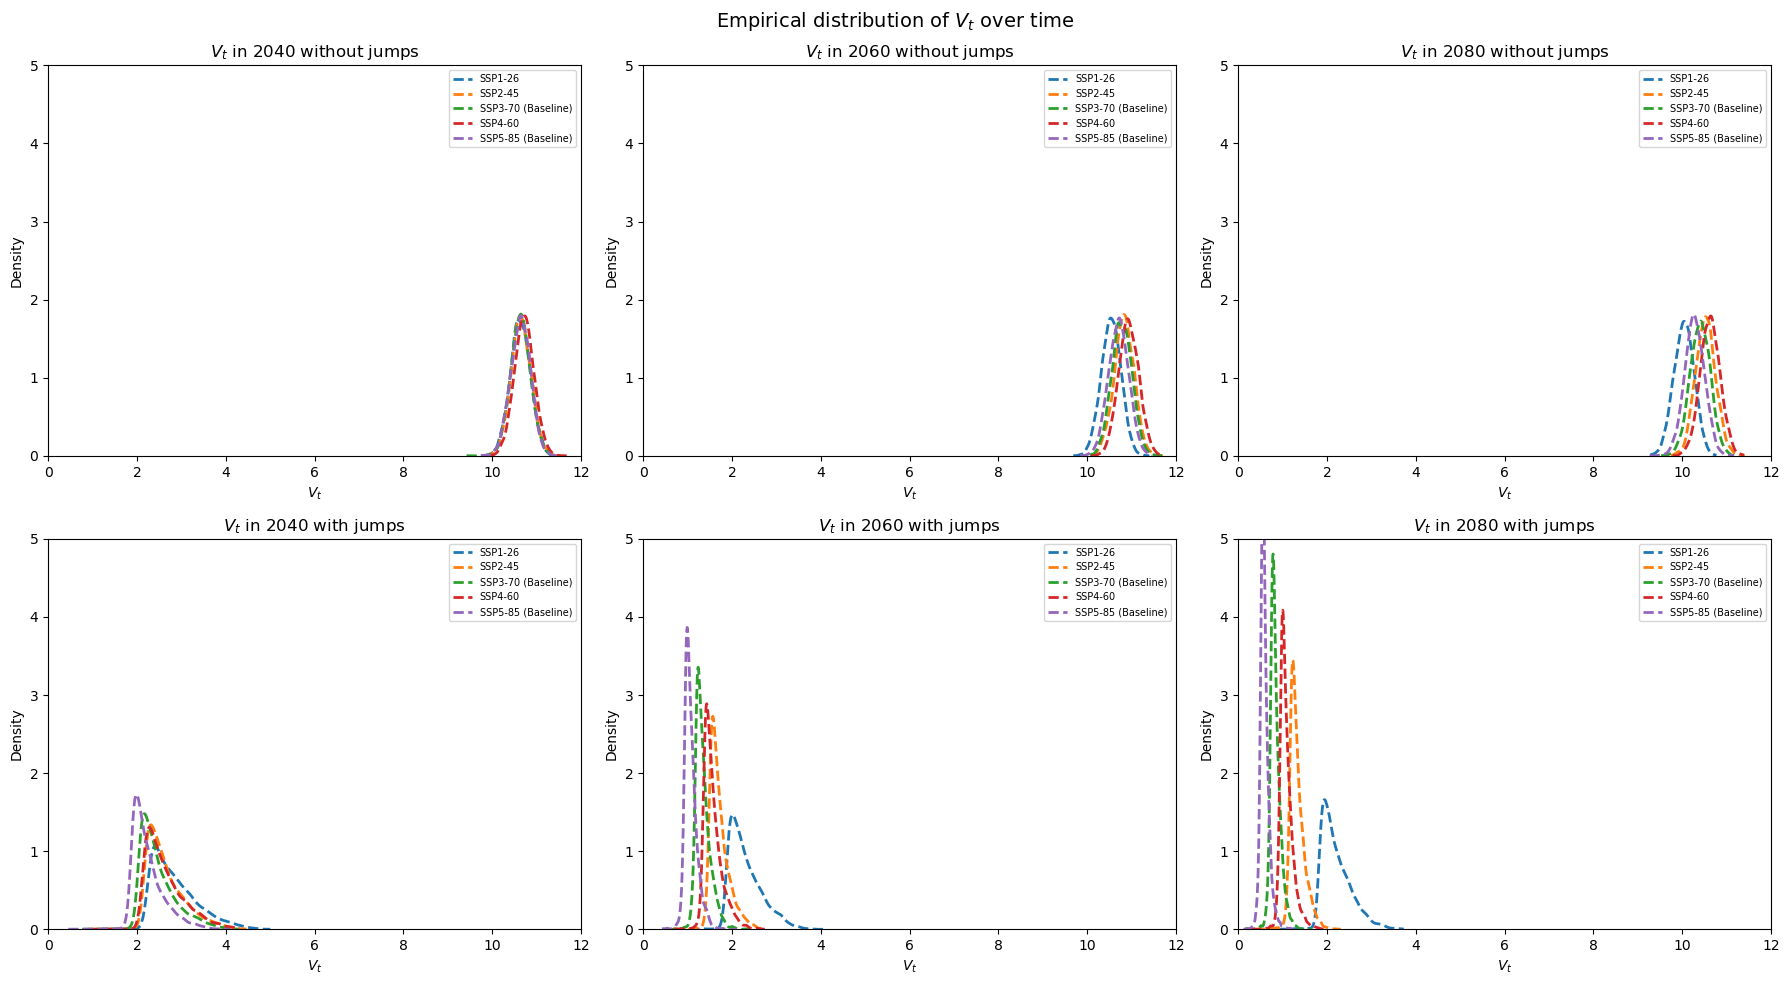

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

years = [25, 45, 65]  # correspond à 2040, 2060, 2080 (base 2015)
years_label = [2040, 2060, 2080]
n = 5000

firm_no_jump = Firm_2(prod_0, r, sig, a, b, c, w_1, w_2, T, alpha, eta, scenario, sector, AP, beta, 0, region, time, "SSP5 - Baseline")
firm_jump = Firm_2(prod_0, r, sig, a, b, c, w_1, w_2, T, alpha, eta, scenario, sector, AP, beta, 0.1, region, time, "SSP5 - Baseline")

for col, (t, year) in enumerate(zip(years, years_label)):
    
    # Ligne 1 : sans sauts
    for i in range(len(SCENARIOS)):
        value_distri = firm_no_jump.multi_value(SCENARIOS[i], SCENARIOS_temp[i], n, t)
        x = np.linspace(np.min(value_distri), np.max(value_distri), n)
        kde = gaussian_kde(value_distri)
        axes[0, col].plot(x, kde(x), label=SCENARIOS[i], linewidth=2, linestyle='--')
    axes[0, col].set_title(rf'$V_t$ in {year} without jumps')
    axes[0, col].legend(fontsize=7)
    axes[0, col].set_xlim(0, 12) 
    axes[0, col].set_ylim(0, 5)
    axes[0, col].set_xlabel(r'$V_t$')
    axes[0, col].set_ylabel('Density')

    # Ligne 2 : avec sauts
    for i in range(len(SCENARIOS)):
        value_distri = firm_jump.multi_value(SCENARIOS[i], SCENARIOS_temp[i], n, t)
        x = np.linspace(np.min(value_distri), np.max(value_distri), n)
        kde = gaussian_kde(value_distri)
        axes[1, col].plot(x, kde(x), label=SCENARIOS[i], linewidth=2, linestyle='--')
    axes[1, col].set_title(rf'$V_t$ in {year} with jumps')
    axes[1, col].legend(fontsize=7)
    axes[1, col].set_xlim(0, 12)  
    axes[1, col].set_ylim(0, 5)
    axes[1, col].set_xlabel(r'$V_t$')
    axes[1, col].set_ylabel('Density')

plt.suptitle(r'Empirical distribution of $V_t$ over time', fontsize=14)
plt.tight_layout()
plt.show()

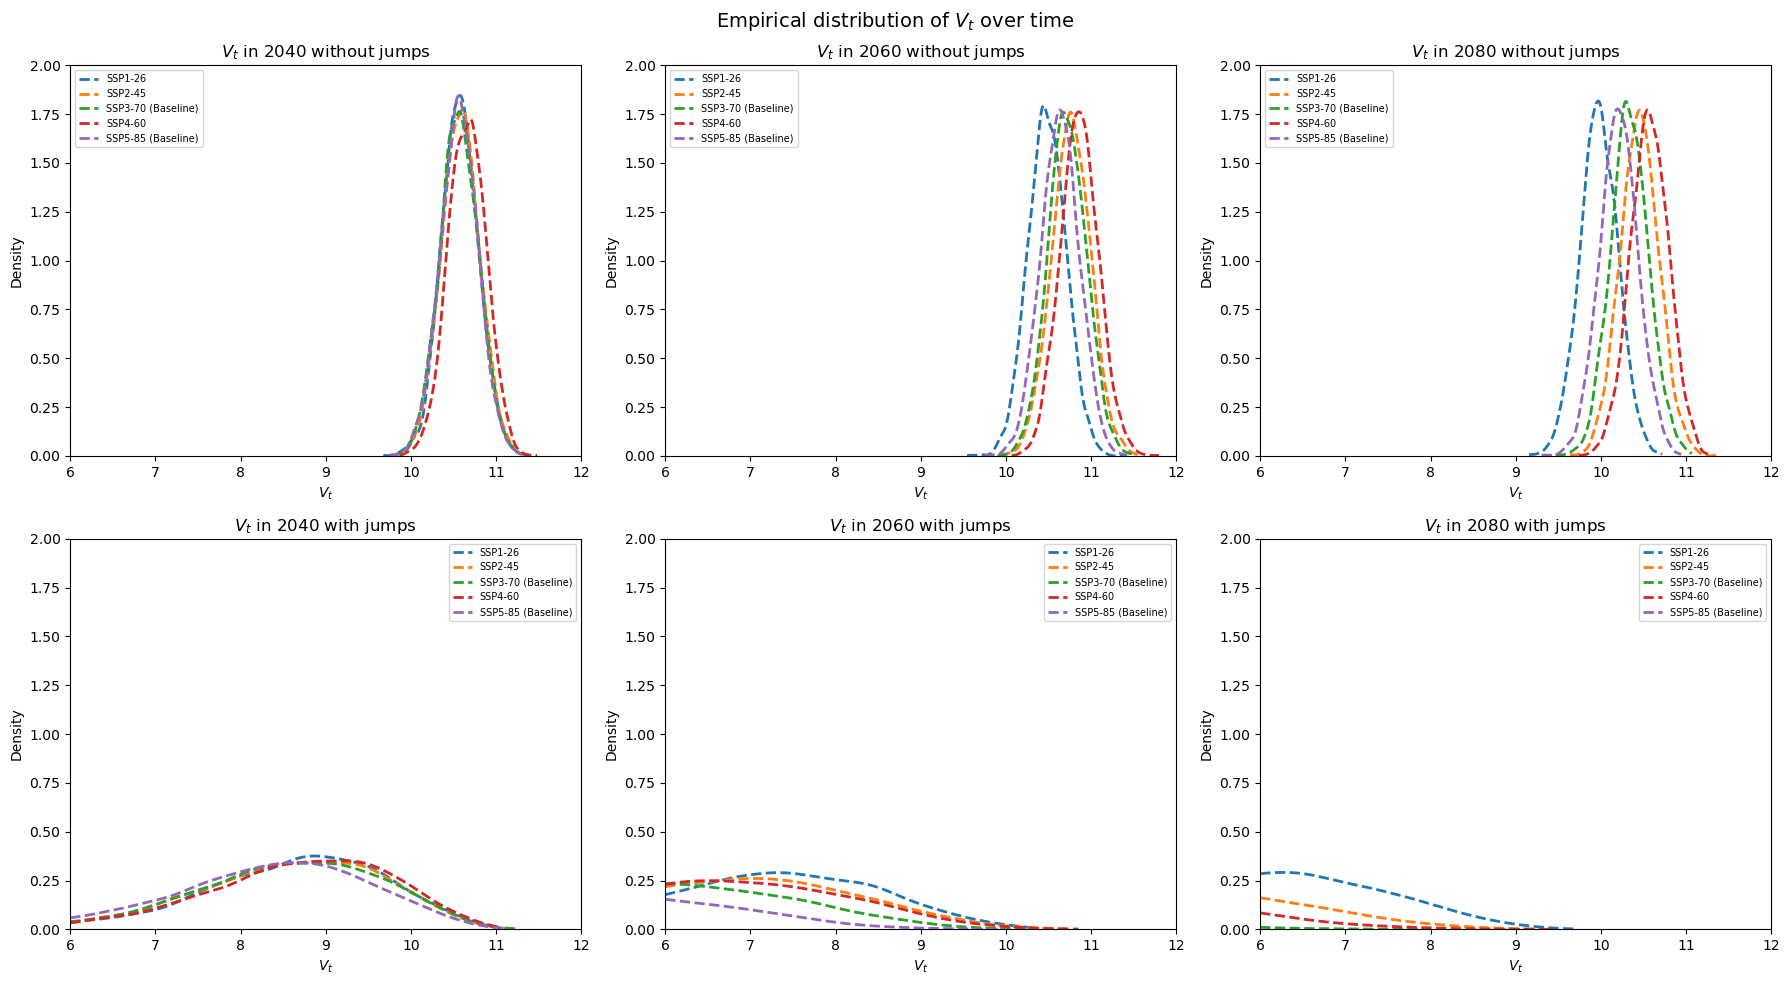

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

years = [25, 45, 65]  # correspond à 2040, 2060, 2080 (base 2015)
years_label = [2040, 2060, 2080]
n = 5000

firm_no_jump = Firm_1(prod_0, r, sig, a, b, c, w_1, w_2, T, alpha, eta, scenario, sector, AP, beta, 0, region, time, "SSP5 - Baseline")
firm_jump = Firm_1(prod_0, r, sig, a, b, c, w_1, w_2, T, alpha, eta, scenario, sector, AP, beta, 0.1, region, time, "SSP5 - Baseline")

for col, (t, year) in enumerate(zip(years, years_label)):
    
    # Ligne 1 : sans sauts
    for i in range(len(SCENARIOS)):
        value_distri = firm_no_jump.multi_value(SCENARIOS[i], SCENARIOS_temp[i], n, t)
        x = np.linspace(np.min(value_distri), np.max(value_distri), n)
        kde = gaussian_kde(value_distri)
        axes[0, col].plot(x, kde(x), label=SCENARIOS[i], linewidth=2, linestyle='--')
    axes[0, col].set_title(rf'$V_t$ in {year} without jumps')
    axes[0, col].legend(fontsize=7)
    axes[0, col].set_xlim(0, 12) 
    axes[0, col].set_ylim(0, 5)
    axes[0, col].set_xlabel(r'$V_t$')
    axes[0, col].set_ylabel('Density')

    # Ligne 2 : avec sauts
    for i in range(len(SCENARIOS)):
        value_distri = firm_jump.multi_value(SCENARIOS[i], SCENARIOS_temp[i], n, t)
        x = np.linspace(np.min(value_distri), np.max(value_distri), n)
        kde = gaussian_kde(value_distri)
        axes[1, col].plot(x, kde(x), label=SCENARIOS[i], linewidth=2, linestyle='--')
    axes[1, col].set_title(rf'$V_t$ in {year} with jumps')
    axes[1, col].legend(fontsize=7)
    axes[1, col].set_xlim(0, 12)  
    axes[1, col].set_ylim(0, 5)
    axes[1, col].set_xlabel(r'$V_t$')
    axes[1, col].set_ylabel('Density')

plt.suptitle(r'Empirical distribution of $V_t$ over time', fontsize=14)
plt.tight_layout()
plt.show()

0
0.01
0.025
0.05
0.1
0.2
0.35
0.5


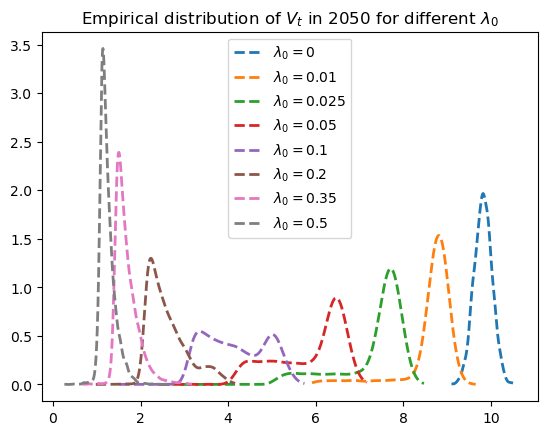

In [5]:
n=5000
lamb=[0,0.01,0.025,0.05,0.1,0.2,0.35,0.5]
for j in lamb:
    print(j)
    firm=Firm_2(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,scenario,sector,AP,beta,j,region,time,"SSP5 - Baseline")
    value_distri=firm.multi_value(SCENARIOS[0],SCENARIOS_temp[0],n,10)
    x = np.linspace(np.min(value_distri), np.max(value_distri), n)
    kde = gaussian_kde(value_distri)
    plt.plot(x, kde(x), label=rf'$\lambda_0={j}$', linewidth=2,linestyle='--')
plt.legend()
plt.title(r'Empirical distribution of $V_t$ in 2050 for different $\lambda_0$')
plt.show()


0
0.01
0.025
0.05
0.1
0.2
0.35
0.5


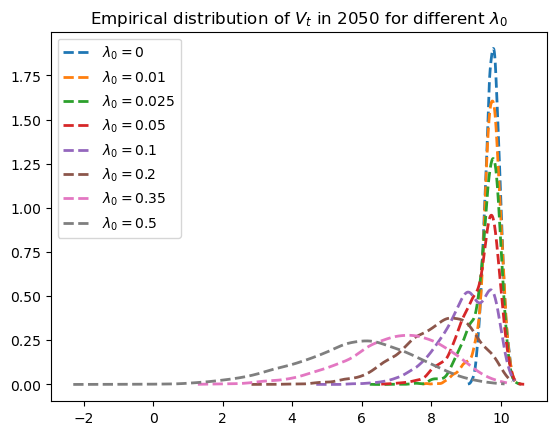

In [6]:
n=5000
lamb=[0,0.01,0.025,0.05,0.1,0.2,0.35,0.5]
for j in lamb:
    print(j)
    firm=Firm_1(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,scenario,sector,AP,beta,j,region,time,"SSP5 - Baseline")
    value_distri=firm.multi_value(SCENARIOS[0],SCENARIOS_temp[0],n,10)
    x = np.linspace(np.min(value_distri), np.max(value_distri), n)
    kde = gaussian_kde(value_distri)
    plt.plot(x, kde(x), label=rf'$\lambda_0={j}$', linewidth=2,linestyle='--')
plt.legend()
plt.title(r'Empirical distribution of $V_t$ in 2050 for different $\lambda_0$')
plt.show()

In [4]:
firm.threshold(SCENARIOS[0],SCENARIOS_temp[0],0.05,35,10000)

9.82058576658153

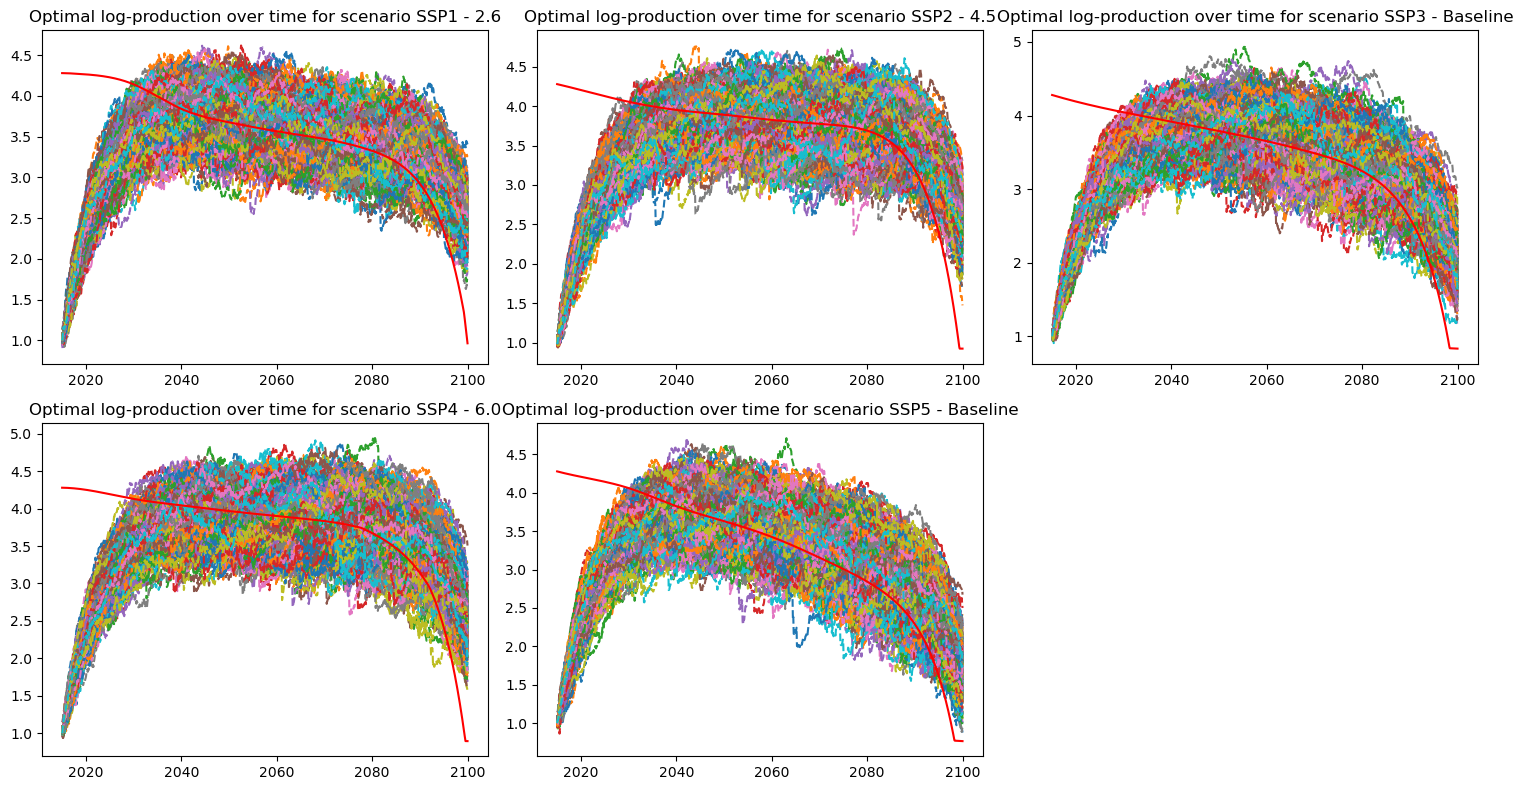

In [5]:
fig, ax = plt.subplots(2, 3, figsize=(15,8))

ax = ax.flatten()  # pour itérer facilement
for i in range (5):
    firm=Firm_2(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,SCENARIOS[i],sector,AP,beta,0.01,region,time,SCENARIOS_temp[i])
    for j in range (500):
        ax[i].plot(years_smooth,firm._trajectoire_pt(SCENARIOS[i],SCENARIOS_temp[i]),label=SCENARIOS[i],linestyle='--')
    ax[i].plot(years_smooth,(a+c*firm.gamma_optimal_control(SCENARIOS_temp[i],SCENARIOS[i]))/(b+firm.beta_t_xi(SCENARIOS_temp[i])*firm.trajectoire_lambda(SCENARIOS_temp[i])),color='red')
    ax[i].set_title(f"Optimal log-production over time for scenario {SCENARIOS_temp[i]}")
fig.delaxes(ax[5])
plt.tight_layout()
plt.show()

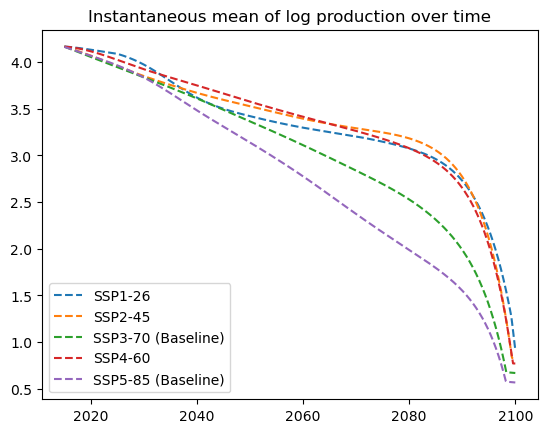

In [7]:
for i in range (5):
    firm=Firm_2(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,SCENARIOS[i],sector,AP,beta,0.01,region,time,SCENARIOS_temp[i])
    plt.plot(years_smooth,(a+c*firm.gamma_optimal_control(SCENARIOS_temp[i],SCENARIOS[i]))/(b+firm.beta_t_xi(SCENARIOS_temp[i])*firm.trajectoire_lambda(SCENARIOS_temp[i])),label=SCENARIOS[i],linestyle='--')
plt.title("Instantaneous mean of log production over time")
plt.legend()

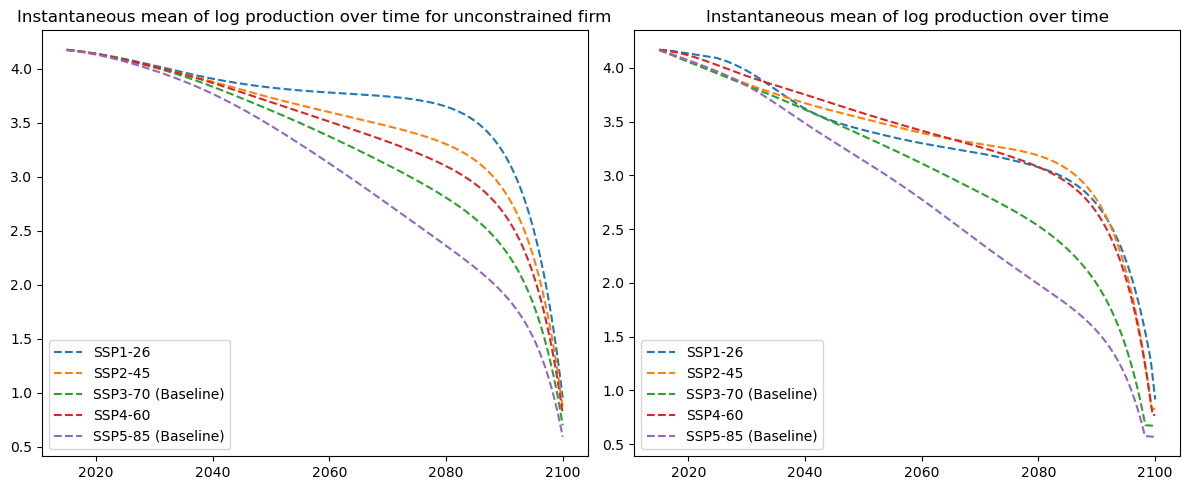

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
for i in range (5):
    firm=Firm_2(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,SCENARIOS[i],sector,AP,beta,0.01,region,time,SCENARIOS_temp[i])
    plt.plot(years_smooth,(a+c*firm.gamma_optimal_unconstrained(SCENARIOS_temp[i]))/(b+firm.beta_t_xi(SCENARIOS_temp[i])*firm.trajectoire_lambda(SCENARIOS_temp[i])),label=SCENARIOS[i],linestyle='--')
plt.title("Instantaneous mean of log production over time for unconstrained firm")
plt.legend()

plt.subplot(1,2,2)

for i in range (5):
    firm=Firm_2(prod_0,r,sig,a,b,c,w_1,w_2,T,alpha,eta,SCENARIOS[i],sector,AP,beta,0.01,region,time,SCENARIOS_temp[i])
    plt.plot(years_smooth,(a+c*firm.gamma_optimal_control(SCENARIOS_temp[i],SCENARIOS[i]))/(b+firm.beta_t_xi(SCENARIOS_temp[i])*firm.trajectoire_lambda(SCENARIOS_temp[i])),label=SCENARIOS[i],linestyle='--')
plt.title("Instantaneous mean of log production over time")
plt.legend()
plt.tight_layout()
plt.show()